# Figure workshop

Design the figures here, with the plotting code inline so it can be edited
directly. Once a figure settles, its code moves into
`scripts/make_figures.py` so every figure can be regenerated with one command
after a rerun.

Until that port happens the script holds an older draft of these figures, so
the notebook is the working copy and the script is stale. Do not edit both.

Each figure cell builds a `fig` and stashes it in `FIGS` via `keep()`. The
inline backend renders it automatically, so the cells deliberately end without
returning anything. The save cell near the bottom writes everything in `FIGS`
to `figures/` as PNG and PDF, so nothing reaches disk until you decide it is
ready.

Re-run the setup cell after editing it, since `keep` is defined there.

In [28]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from constellaration_uq.data import filter_valid, load_raw
from constellaration_uq.results import REPO_ROOT, load_results
from constellaration_uq.splits import (
    distance_from_training_region,
    hole_split,
    tail_split,
)

DATA_DIR = REPO_ROOT / 'data_raw' / 'data'
FIGURES_DIR = REPO_ROOT / 'figures'
AXIS = 'metrics.aspect_ratio'
TEST_FRACTION = 0.2

# Percentile 30, so the band runs 20 to 40. Chosen from scripts/hole_placement.py:
# it sits immediately above the tail's percentiles 0 to 20 without overlapping,
# so the hole-versus-edge contrast controls for local sparsity. Defined once here
# because several figures use it and a hardcoded default would drift between them.
HOLE_CENTRE = 0.30

FIGS = {}


def keep(fig, name):
    """Stash a figure for the save cell.

    Deliberately returns nothing. %matplotlib inline already renders every
    figure a cell creates, so returning it would make the cell's output value
    render it a second time and every figure would appear twice.
    """
    FIGS[name] = fig

## Style

Edit here rather than per figure. The same colour must mean the same thing
everywhere, which matters more than any individual choice.

In [29]:
COLOR_TRAIN = '#9ecae1'
COLOR_TAIL = '#d94801'
COLOR_HOLE = '#2171b5'
COLOR_NEUTRAL = '#525252'

plt.rcParams.update(
    {
        'figure.figsize': (8, 4.5),
        'figure.dpi': 110,
        'savefig.dpi': 150,
        'savefig.bbox': 'tight',
        'axes.grid': True,
        'grid.alpha': 0.25,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 10,
    }
)

## Load the axis

Slow cell, roughly 10 to 20 seconds, almost all of it reading parquet. Only the
aspect ratio column is needed, never the 80-coefficient flatten. Run once.

In [30]:
for _, _df in filter_valid(load_raw(DATA_DIR)):
    pass

axis = _df[AXIS].to_numpy()
print(f'{len(axis):,} rows, aspect ratio {axis.min():.2f} to {axis.max():.2f}')

27,050 rows, aspect ratio 3.92 to 12.11


## Figure 1: where the cuts fall

The explanatory figure. Shows the sampling density, where the tail cut lands,
and how narrow the hole is by comparison.

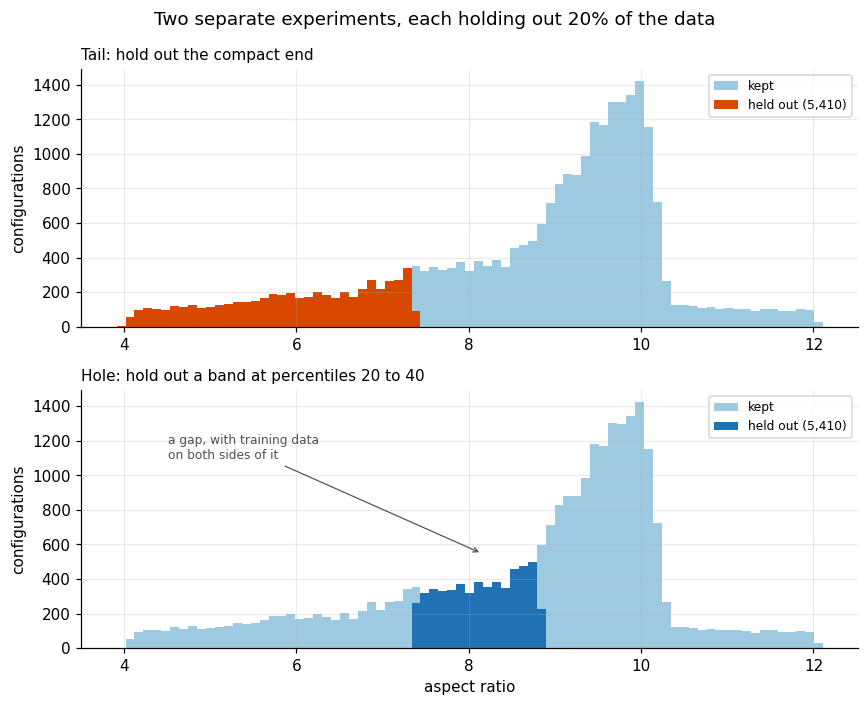

In [31]:
_, tail_test = tail_split(axis, 'low', TEST_FRACTION)
_, hole_test = hole_split(axis, TEST_FRACTION, HOLE_CENTRE)

fig, (ax_tail, ax_hole) = plt.subplots(2, 1, sharex=False, figsize=(8, 6.5))
bins = np.linspace(axis.min(), axis.max(), 80)

panels = [
    (ax_tail, tail_test, COLOR_TAIL, 'Tail: hold out the compact end'),
    (ax_hole, hole_test, COLOR_HOLE, f'Hole: hold out a band at percentiles 20 to 40'),
]

for ax, test_mask, color, title in panels:
    ax.hist(axis, bins=bins, color=COLOR_TRAIN, label='kept')
    ax.hist(axis[test_mask], bins=bins, color=color, label=f'held out ({test_mask.sum():,})')
    ax.set_ylabel('configurations')
    ax.set_title(title, fontsize=10, loc='left')
    ax.legend(fontsize=8)

# Tip height derived from the bars so it lands on them rather than above.
hole_counts, _ = np.histogram(axis[hole_test], bins=bins)

ax_hole.annotate(
    'a gap, with training data\non both sides of it',
    xy=(axis[hole_test].mean(), hole_counts.max() * 1.10),
    xytext=(axis.min() + 0.6, hole_counts.max() * 2.2),
    fontsize=8,
    color=COLOR_NEUTRAL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_NEUTRAL, 'lw': 0.8},
)


ax_hole.set_xlabel('aspect ratio')
fig.suptitle('Two separate experiments, each holding out 20% of the data')
fig.tight_layout()

keep(fig, 'split_design')


## Figure 2: how far each split reaches

The hole and the tail hold out the same number of configurations but cover very
different amounts of design space, because the compact end is sparse and the
middle is dense.

This bounds where a "at matched distance" comparison is possible: only over the
range both splits occupy. With the hole at percentile 30 that range runs 0 to
about 0.45, which is workable. At the original median placement it was 0 to
0.20, which was not.

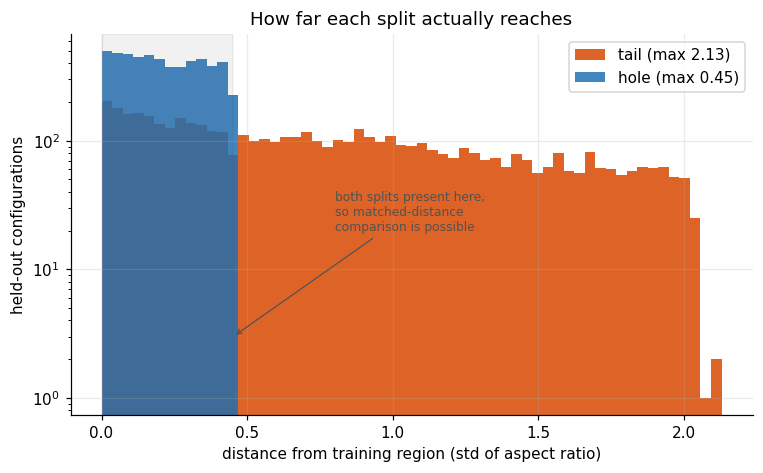

In [32]:
tail_train, tail_test = tail_split(axis, 'low', TEST_FRACTION)
hole_train, hole_test = hole_split(axis, TEST_FRACTION, HOLE_CENTRE)

tail_d = distance_from_training_region(axis, tail_train)[tail_test]
hole_d = distance_from_training_region(axis, hole_train)[hole_test]

fig, ax = plt.subplots()
bins = np.linspace(0, max(tail_d.max(), hole_d.max()), 60)

ax.hist(tail_d, bins=bins, color=COLOR_TAIL, alpha=0.85, label=f'tail (max {tail_d.max():.2f})')
ax.hist(hole_d, bins=bins, color=COLOR_HOLE, alpha=0.85, label=f'hole (max {hole_d.max():.2f})')

ax.axvspan(0, hole_d.max(), color=COLOR_NEUTRAL, alpha=0.08)
ax.annotate(
    'both splits present here,\nso matched-distance\ncomparison is possible',
    xy=(hole_d.max(), 3),
    xytext=(hole_d.max() + 0.35, 20),
    fontsize=8,
    color=COLOR_NEUTRAL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_NEUTRAL, 'lw': 0.8},
)

ax.set_yscale('log')
ax.set_xlabel('distance from training region (std of aspect ratio)')
ax.set_ylabel('held-out configurations')
ax.set_title('How far each split actually reaches')
ax.legend()

keep(fig, 'distance_reach')

## Hole placement: a decision, not a figure

The placement sweep asked one question, where to centre the interior hole, and
answered it: percentile 30, which sits immediately above the tail's percentiles
0 to 20 without overlapping them. That makes it a design-decision record, so it
is a table.

Two earlier attempts to plot it are gone. Both drew eight independent
experiments as points on a single axis, and both were misread, because nothing
in that picture tells a reader that each point is its own model fit rather than
a sample from one curve.

`results/hole_placement.json` is the 20% sweep, centres p20 to p80.
`results/hole_placement_narrow.json` is a 10% sweep, centres p10 to p90, and it
is the only run that reaches the sparse upper end. The narrow run shows the
penalty is a U in placement, lowest in the dense middle and rising at both ends,
which means gap width rather than proximity to the compact edge drives most of
it. Treat that as suggestive: its two load-bearing rows carry about 130 points
in their thinnest distance bin against roughly 310 elsewhere, at a single seed.


In [33]:
import pandas as pd

sweep = load_results('hole_placement')['results']['rows']

pd.DataFrame(sweep)[
    [
        'split',
        'percentiles',
        'n_held_out',
        'rmse_in',
        'rmse_out',
        'ratio',
        'reach',
        'min_bin',
        'delta',
    ]
].round({'rmse_in': 5, 'rmse_out': 5, 'ratio': 2, 'reach': 2, 'delta': 3})

,split,percentiles,n_held_out,rmse_in,rmse_out,ratio,reach,min_bin,delta
0,tail-low,0 to 20,5405,0.01379,0.04157,3.02,2.13,276,0.059
1,hole,10 to 30,5404,0.01417,0.02777,1.96,0.63,602,0.040
2,hole,20 to 40,5404,0.01452,0.02615,1.80,0.45,583,0.041
3,hole,30 to 50,5404,0.01479,0.01658,1.12,0.31,586,0.040
4,hole,40 to 60,5404,0.01476,0.01406,0.95,0.20,641,0.039
5,hole,50 to 70,5404,0.01526,0.01377,0.90,0.16,616,0.039
6,hole,60 to 80,5404,0.01552,0.01240,0.80,0.14,645,0.039
7,hole,70 to 90,5404,0.01567,0.01283,0.82,0.13,602,0.040


## Figure 3: error against distance from the training data

Deliverable one, in single-model form. Every point on these curves is a bin of
roughly 675 held-out configurations rather than a whole experiment, which is
what makes it readable in a way the placement sweep never was.

Three splits, one MLP each, same recipe as the day 1-2 grid. Each curve starts
at that split's own in-region error, measured on a held-out slice carved from
the training region, then follows the binned error outward.

**The finding.** At matched distance the tail sits consistently above the hole,
by roughly 15% at both 0.2 and 0.4 standard deviations out. So most of the
headline gap, 3.02 against 1.80, is distance rather than edge: the tail split
simply asks about configurations much further from the data. What survives after
distance is controlled for is the edge premium itself, and it is real but modest.

The shaded band is the only range where both splits have points, so it is the
only range where that comparison exists at all. Past 0.45 the tail continues
alone, and nothing can be said about how a gap would behave out there.

Reads `results/distance_error.json`. Per-point rows are in
`results/distance_error_points.csv` if the bins ever need redrawing.


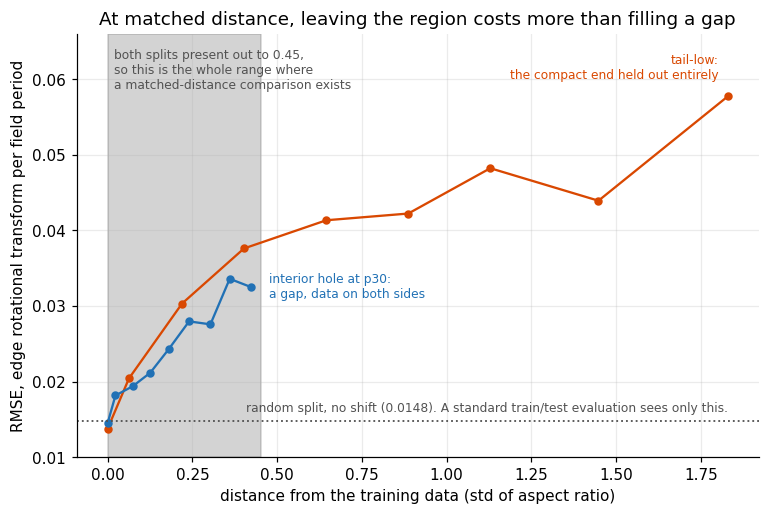

In [46]:
splits = load_results('distance_error')['results']['splits']

# Direct labels instead of a legend. Two series only, and the legend box was
# landing on the baseline label in the one corner both wanted.
SERIES = {
    'tail_low': (
        'tail-low:\nthe compact end held out entirely',
        COLOR_TAIL,
        {'xytext': (-6, 12), 'ha': 'right'},
    ),
    'hole_p30': (
        'interior hole at p30:\na gap, data on both sides',
        COLOR_HOLE,
        {'xytext': (12, 0), 'ha': 'left', 'va': 'center'},
    ),
}

fig, ax = plt.subplots(figsize=(8, 5))

# Pinned so the annotations below have somewhere reliable to sit.
ax.set_ylim(0.010, 0.066)

for name, (label, color, placement) in SERIES.items():
    split = splits[name]
    # Each curve starts from its own in-region error at distance zero rather
    # than from a shared baseline. The two differ by about 5%, and drawing one
    # line for both would hide that.
    d = [0.0, *[b['d_median'] for b in split['bins']]]
    err = [split['in_region']['rmse'], *[b['rmse'] for b in split['bins']]]
    ax.plot(d, err, 'o-', color=color, markersize=4.5)
    ax.annotate(
        label,
        (d[-1], err[-1]),
        textcoords='offset points',
        fontsize=8,
        color=color,
        **placement,
    )

# The random split is a reference level, not a series. Its held-out points never
# get more than 0.01 from training data, so drawn as a curve it is eight dots on
# the y axis that read as noise on the other two. As a line it does the job it is
# actually for: making the vertical gap to the no-shift baseline readable at
# every distance.
random = splits['random']
far = splits['tail_low']['bins'][-1]['d_median']
ax.axhline(random['rmse_out'], color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    f'random split, no shift ({random["rmse_out"]:.4f}). '
    'A standard train/test evaluation sees only this.',
    (far, random['rmse_out']),
    textcoords='offset points',
    xytext=(0, 6),
    ha='right',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

# The hole cannot reach past here, so neither can the comparison. Sits inside
# the band, top left, where both curves are still low.
overlap = splits['hole_p30']['reach']
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)
ax.annotate(
    f'both splits present out to {overlap:.2f},\nso this is the whole range where\n'
    'a matched-distance comparison exists',
    (0.02, 0.064),
    va='top',
    ha='left',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('RMSE, edge rotational transform per field period')
ax.set_title('At matched distance, leaving the region costs more than filling a gap')

keep(fig, 'distance_error')


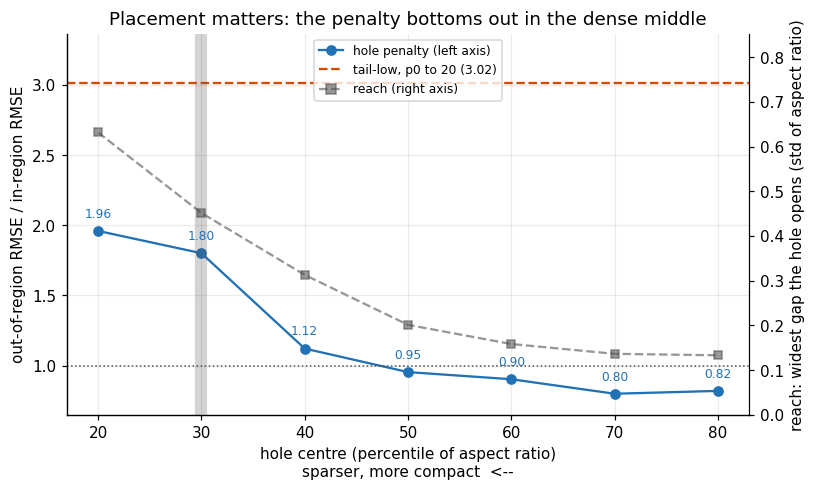

In [35]:
PLACEMENT_RESULTS = 'hole_placement'  # 'hole_placement_narrow' for the 10% sweep

_placement = load_results(PLACEMENT_RESULTS)
placement = _placement['results']['rows']

# Band width comes from the run that produced these numbers, not from the
# notebook's TEST_FRACTION. The narrow sweep held out 10%, so a hardcoded 0.2
# would draw every band at twice its real width and put the boundary line in
# the wrong place, which would look plausible and be wrong.
placement_fraction = _placement['constants']['TEST_FRACTION']

holes = [r for r in placement if r['split'] == 'hole']
tail = next(r for r in placement if r['split'] == 'tail-low')
holes.sort(key=lambda r: r['centre'])

centres = [r['centre'] * 100 for r in holes]
ratios = [r['ratio'] for r in holes]
reaches = [r['reach'] for r in holes]

fig, ax = plt.subplots()

# Reach goes on the twin and stays recessive, because it is the explanation
# rather than the result. Same stacking trick as the density figure: raise the
# ratio axis and clear its patch so its markers draw over the reach line.
ax_reach = ax.twinx()
ax_reach.plot(centres, reaches, 's--', color=COLOR_NEUTRAL, alpha=0.6, markersize=5)
ax_reach.grid(False)
ax_reach.set_ylim(0, max(reaches) * 1.35)
ax_reach.set_ylabel('reach: widest gap the hole opens (std of aspect ratio)')
ax_reach.spines['right'].set_visible(True)

ax.set_zorder(ax_reach.get_zorder() + 1)
ax.patch.set_visible(False)

ax.plot(centres, ratios, 'o-', color=COLOR_HOLE)
for r in holes:
    ax.annotate(
        f'{r["ratio"]:.2f}',
        (r['centre'] * 100, r['ratio']),
        textcoords='offset points',
        xytext=(0, 9),
        ha='center',
        fontsize=8,
        color=COLOR_HOLE,
    )

# The tail is a reference level, not a point on this curve. Its held-out band
# reaches 2.13 against the widest hole's 0.63, so it does not belong on the
# reach axis, and a line drawn through both would be the extrapolation this
# project exists to criticise.
ax.axhline(tail['ratio'], color=COLOR_TAIL, linestyle='--')
ax.axhline(1.0, color=COLOR_NEUTRAL, linestyle=':', linewidth=1)

# The chosen placement, and the one the edge effect is measured against.
ax.axvline(HOLE_CENTRE * 100, color=COLOR_NEUTRAL, alpha=0.25, linewidth=8)

_ratios = [r['ratio'] for r in [tail, *holes]]
ax.set_ylim(min(_ratios) - 0.15, max(_ratios) + 0.35)

ax.set_xlabel('hole centre (percentile of aspect ratio)\nsparser, more compact  <--')
ax.set_ylabel('out-of-region RMSE / in-region RMSE')
ax.set_title('Placement matters: the penalty bottoms out in the dense middle')
ax.legend(
    handles=[
        plt.Line2D([], [], color=COLOR_HOLE, marker='o', label='hole penalty (left axis)'),
        plt.Line2D(
            [],
            [],
            color=COLOR_TAIL,
            linestyle='--',
            label=f'tail-low, p{tail["percentiles"]} ({tail["ratio"]:.2f})',
        ),
        plt.Line2D(
            [],
            [],
            color=COLOR_NEUTRAL,
            marker='s',
            linestyle='--',
            alpha=0.6,
            label='reach (right axis)',
        ),
    ],
    fontsize=8,
    loc='upper center',
)

keep(fig, 'hole_placement')


## Load saved results

Everything below reads `results/*.json`, so it needs the corresponding analysis
script to have been run. Fast, under a second.

In [36]:
grid = load_results('day_1_2_grid')['results']
noise = load_results('stage_2_noise_floor')['results']
gate = load_results('gate_3_5_split_axis')['results']

print('grid rows:', len(grid['rows']))
print('noise floor targets:', list(noise['residual_spread']))
print('gate verdict:', gate['verdict'])

grid rows: 12
noise floor targets: ['edge_rot_transform', 'log10_qi']
gate verdict: INCONCLUSIVE


## Figure 3: generalization gap by axis and cut

The day 1-2 result in one picture. The reference line at 1.0 is where holding
data out costs nothing.

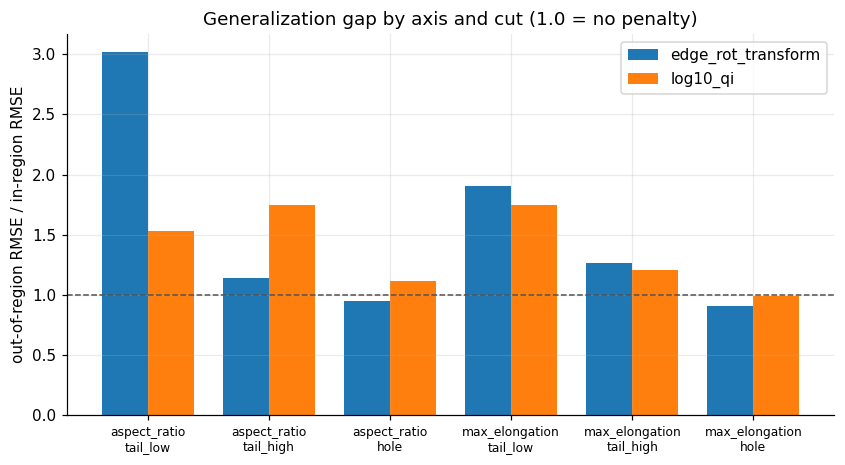

In [37]:
rows = grid['rows']
targets = sorted({r['target'] for r in rows})

combos = []
for r in rows:
    if (r['axis'], r['cut']) not in combos:
        combos.append((r['axis'], r['cut']))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(combos))
width = 0.38

for i, target in enumerate(targets):
    values = [
        next(r['ratio'] for r in rows if (r['axis'], r['cut']) == c and r['target'] == target)
        for c in combos
    ]
    ax.bar(x + (i - 0.5) * width, values, width, label=target)

ax.axhline(1.0, color=COLOR_NEUTRAL, linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f'{a}\n{c}' for a, c in combos], fontsize=8)
ax.set_ylabel('out-of-region RMSE / in-region RMSE')
ax.set_title('Generalization gap by axis and cut (1.0 = no penalty)')
ax.legend()

keep(fig, 'grid_ratios')

## Figure 4: the noise floor

The dashed line is fitted to the three closest bins and extended back to zero
distance. Its intercept is the floor estimate, which is the point of the figure.

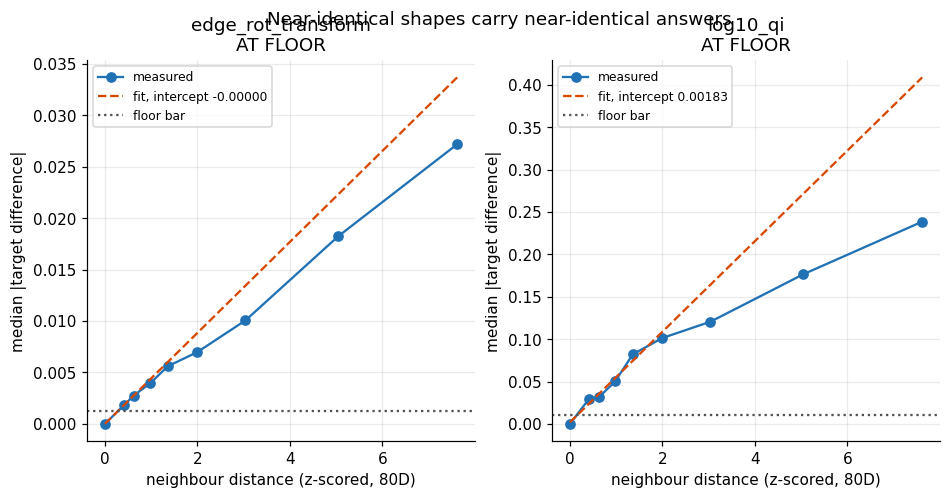

In [38]:
spread = noise['residual_spread']

fig, axes = plt.subplots(1, len(spread), figsize=(10, 4.5))
axes = np.atleast_1d(axes)

for ax, (name, result) in zip(axes, spread.items(), strict=False):
    d = [b['median_distance'] for b in result['bins']]
    gap = [b['median_delta'] for b in result['bins']]

    ax.plot(d, gap, 'o-', color=COLOR_HOLE, label='measured')

    xs = np.linspace(0, max(d), 50)
    ax.plot(
        xs,
        result['intercept'] + result['slope'] * xs,
        '--',
        color=COLOR_TAIL,
        label=f'fit, intercept {result["intercept"]:.5f}',
    )
    ax.axhline(result['bar'], color=COLOR_NEUTRAL, linestyle=':', label='floor bar')

    ax.set_xlabel('neighbour distance (z-scored, 80D)')
    ax.set_ylabel('median |target difference|')
    ax.set_title(f'{name}\n{result["verdict"]}')
    ax.legend(fontsize=8)

fig.suptitle('Near-identical shapes carry near-identical answers')

keep(fig, 'noise_floor')

## Figure 5: error tracks data density

From gate 3.5. Supporting evidence, and notable because it shows the
extrapolation premise in a purely geometric quantity, before any surrogate
exists.

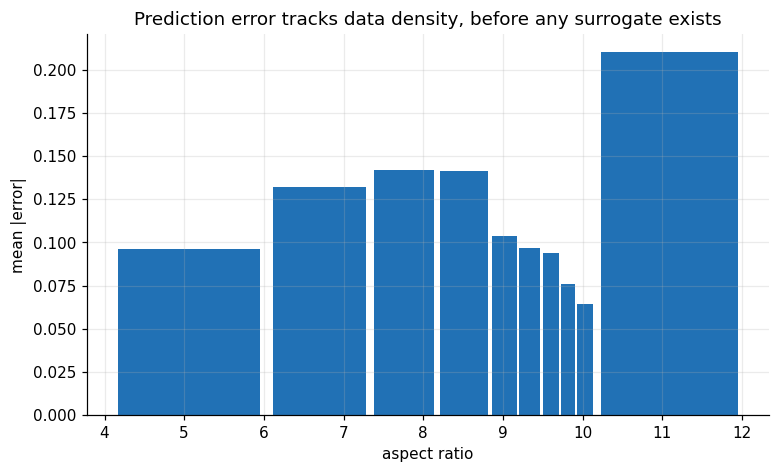

In [39]:
deciles = gate['deciles']

centres = [(d['lo'] + d['hi']) / 2 for d in deciles]
errors = [d['mean_abs_error'] for d in deciles]
widths = [(d['hi'] - d['lo']) * 0.9 for d in deciles]

fig, ax = plt.subplots()
ax.bar(centres, errors, width=widths, color=COLOR_HOLE)

ax.set_xlabel('aspect ratio')
ax.set_ylabel('mean |error|')
ax.set_title('Prediction error tracks data density, before any surrogate exists')

keep(fig, 'gate_3_5_deciles')

## Save

Writes everything stashed in `FIGS` to `figures/` as PNG and PDF. Only the
figures whose cells you have run are present, so re-run a cell before saving if
you changed it.

In [40]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for name, fig in FIGS.items():
    for suffix in ('png', 'pdf'):
        fig.savefig(FIGURES_DIR / f'{name}.{suffix}')
    print(f'wrote figures/{name}.png and .pdf')

wrote figures/split_design.png and .pdf
wrote figures/distance_reach.png and .pdf
wrote figures/distance_error.png and .pdf
wrote figures/hole_placement.png and .pdf
wrote figures/grid_ratios.png and .pdf
wrote figures/noise_floor.png and .pdf
wrote figures/gate_3_5_deciles.png and .pdf


## Scratch

Prototype new figures here. When one settles, give it a `keep(fig, 'name')` and
add it to the port list for `scripts/make_figures.py`.